# Project data exploration - looking at relplot and scatter plots
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships

Group name: team 1 
Created by Alex Hovakimyan(016319888), Gloria Duo(), Julie Nguyen(015783807), name4()  
Last updated:   
Briefly describe your dataset

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

### Load Data

In [8]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

data_path = Path('data') / 'baseline_dataset.parquet'

df = pd.read_parquet(data_path)
pd.set_option('display.max_columns', None)

### Q1: Show the number of missing data in each column of the dataframe

In [9]:
# Your code here . . .
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values)

min_val_temperature        67583
last_val_temperature       67583
mean_val_temperature       67583
max_val_temperature        67583
mean_val_bilirubin         40917
                           ...  
ICU_mortality                  0
ICU_endtime                    0
ICU_time_to_event_hours        0
window_24h_end                 0
subject_id                     0
Length: 66, dtype: int64


### Q2: Show the data type for each column of the dataframe

In [10]:
# Your code here . . .
print(df.dtypes)

subject_id                     int32
hadm_id                        int32
stay_id                        int32
first_careunit                object
intime                datetime64[us]
                           ...      
last_val_lactate             float64
last_val_platelets           float64
last_val_potassium           float64
last_val_sodium              float64
last_val_wbc                 float64
Length: 66, dtype: object


### Q3: Create a pair plot to show pairwise relationship in this dataset.
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

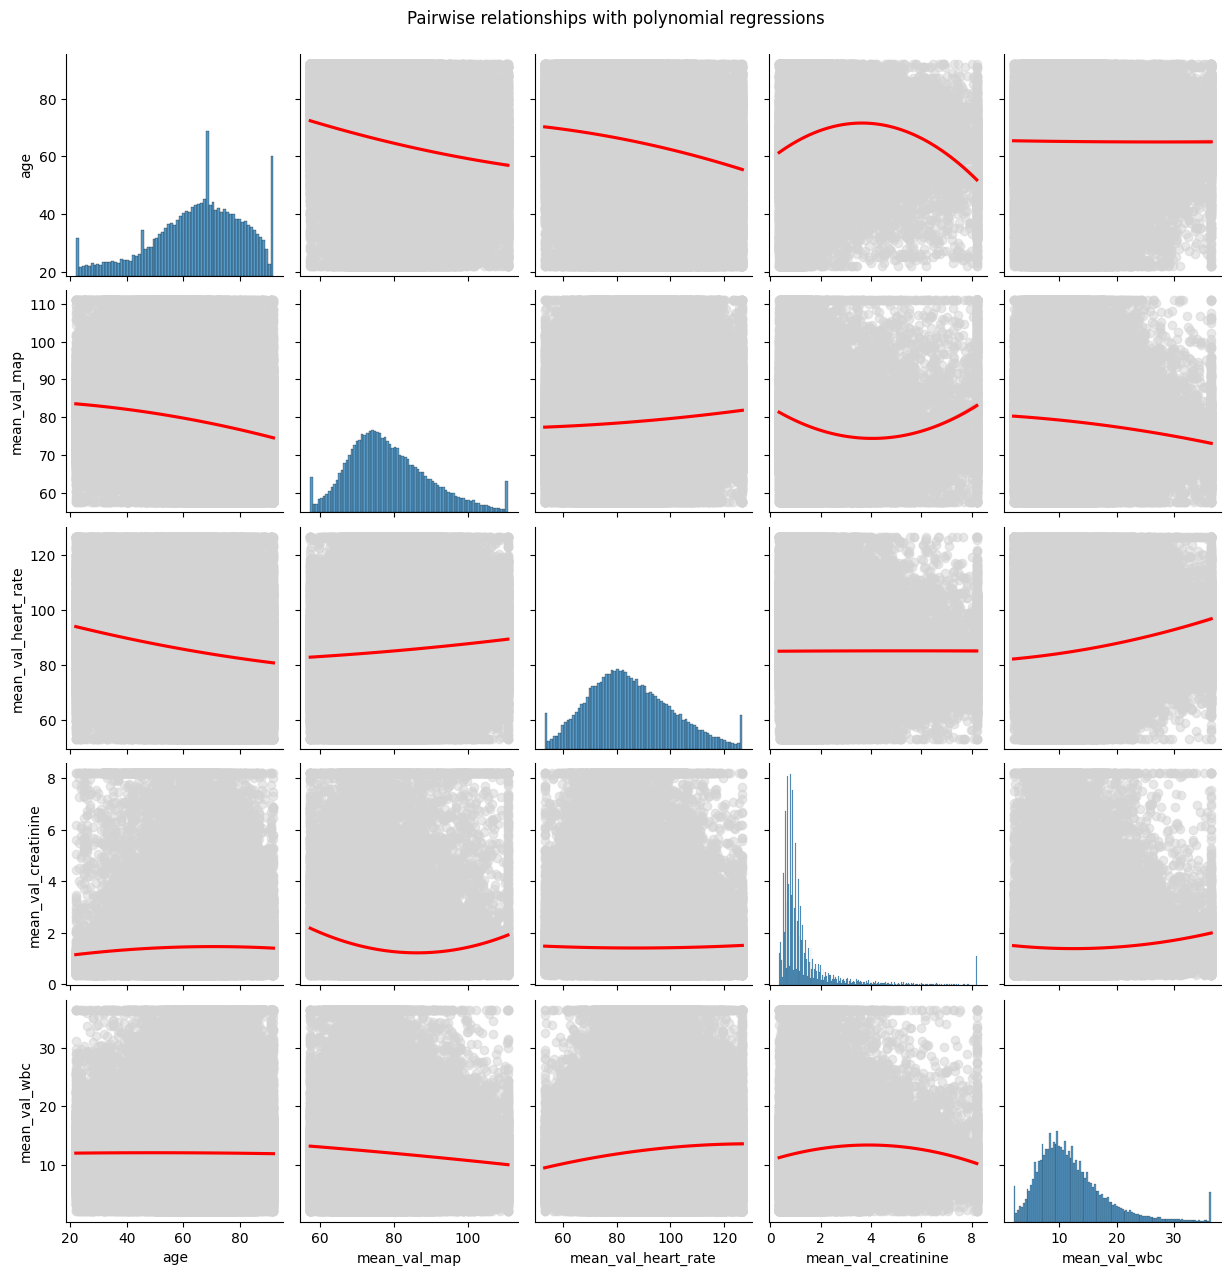

In [4]:
# we pick specific columns because it will
# otherwise take too long to plot 64 x 64 columns
interesting_cols = [
    'age', 
    'mean_val_map', 
    'mean_val_heart_rate', 
    'mean_val_creatinine', 
    'mean_val_wbc'
]

plot_df = df[interesting_cols].dropna()

# to zoom out the points
plot_df = plot_df.clip(             
   lower=plot_df.quantile(0.01),   
   upper=plot_df.quantile(0.99),   
   axis=1                          
)     
graph = sns.pairplot(data=plot_df, kind="reg", 
                     plot_kws={
                        'order': 2,
                        'scatter_kws': {'color': 'lightgray', 'alpha': 0.5},
                        'line_kws': {'color': 'red'}
                     }
)

graph.figure.suptitle("Pairwise relationships with polynomial regressions", y=1.02)
plt.show()

### Q4: Plot a regression line and confidence interval
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

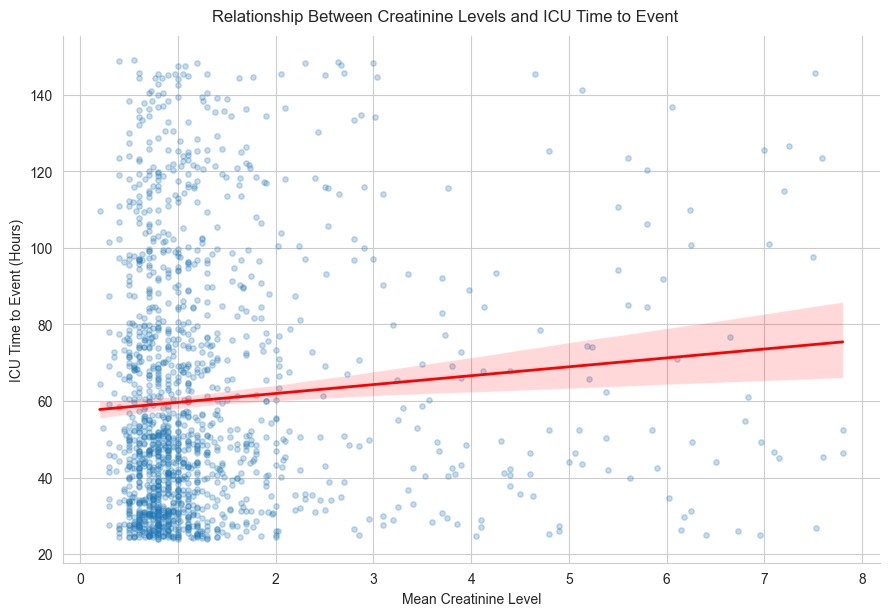

In [5]:
# Your code here . . .

import seaborn as sns
import matplotlib.pyplot as plt

clean_data = df.dropna(subset=["mean_val_creatinine", "ICU_time_to_event_hours"])

clean_data = clean_data[
    (clean_data["mean_val_creatinine"] <= 8) &
    (clean_data["ICU_time_to_event_hours"] <= 150)
]

sample_data = clean_data.sample(1500, random_state=42)

sns.set_style("whitegrid")

plot = sns.lmplot(
    data=sample_data,
    x="mean_val_creatinine",
    y="ICU_time_to_event_hours",
    ci=95,
    height=6,
    aspect=1.5,
    scatter_kws={"alpha": 0.25, "s": 15},
    line_kws={"color": "red", "linewidth": 2}
)

plot.fig.suptitle(
    "Relationship Between Creatinine Levels and ICU Time to Event",
    y=1.02
)

plot.set_axis_labels(
    "Mean Creatinine Level",
    "ICU Time to Event (Hours)"
)

plt.show()

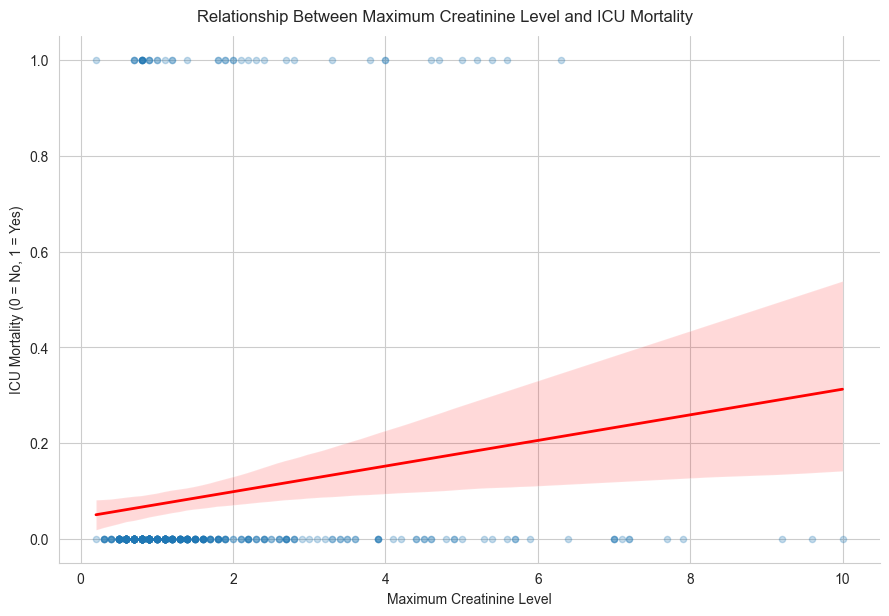

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

clean_data = df.dropna(subset=["max_val_creatinine", "ICU_mortality"])

clean_data = clean_data[clean_data["max_val_creatinine"] <= 10]

sample_data = clean_data.sample(500, random_state=42)

sns.set_style("whitegrid")

plot = sns.lmplot(
    data=sample_data,
    x="max_val_creatinine",
    y="ICU_mortality",
    ci=95,
    height=6,
    aspect=1.5,
    scatter_kws={"alpha": 0.25, "s": 20},
    line_kws={"color": "red", "linewidth": 2}
)


plot.fig.suptitle(
    "Relationship Between Maximum Creatinine Level and ICU Mortality",
    y=1.02
)

plot.set_axis_labels(
    "Maximum Creatinine Level",
    "ICU Mortality (0 = No, 1 = Yes)"
)

plt.show()

### Q5. Create a relplot that shows multiple features in a single plot.
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

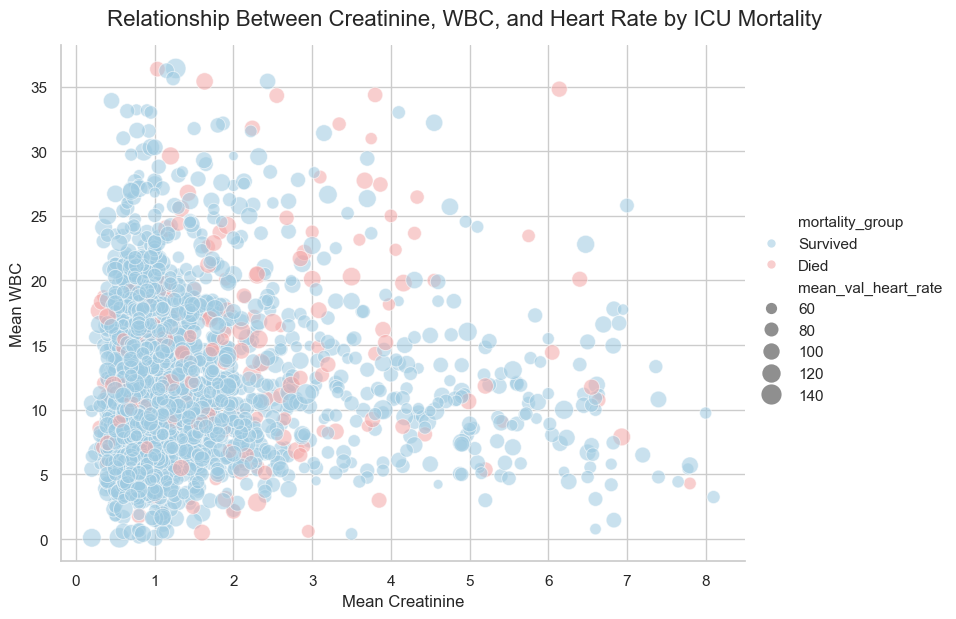

In [7]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_path = Path("data") / "baseline_dataset.parquet"
df = pd.read_parquet(data_path)

plot_df = df[[
    "mean_val_creatinine",
    "mean_val_wbc",
    "mean_val_heart_rate",
    "ICU_mortality"
]].dropna().copy()

plot_df = plot_df[
    (plot_df["mean_val_creatinine"] <= plot_df["mean_val_creatinine"].quantile(0.99)) &
    (plot_df["mean_val_wbc"] <= plot_df["mean_val_wbc"].quantile(0.99)) &
    (plot_df["mean_val_heart_rate"] >= 40) &
    (plot_df["mean_val_heart_rate"] <= 150)
].copy()

plot_df["mortality_group"] = plot_df["ICU_mortality"].astype(int).map({
    0: "Survived",
    1: "Died"
})

plot_df = plot_df.reset_index(drop=True)

if len(plot_df) > 3000:
    plot_df = plot_df.sample(3000, random_state=42).reset_index(drop=True)

sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=plot_df,
    x="mean_val_creatinine",
    y="mean_val_wbc",
    hue="mortality_group",
    size="mean_val_heart_rate",
    kind="scatter",
    sizes=(30, 220),
    alpha=0.55,
    height=6,
    aspect=1.3,
    palette={"Survived": "#9ecae1", "Died": "#f4a6a6"}
)

g.set_axis_labels("Mean Creatinine", "Mean WBC")

g.fig.suptitle(
    "Relationship Between Creatinine, WBC, and Heart Rate by ICU Mortality",
    fontsize=16,
    y=1.03
)

plt.show()

### Interpretation

This plot shows the relationship between creatinine, white blood cell count, and heart rate, with color indicating whether a patient survived or died.

Patients with higher creatinine, higher WBC, and higher heart rate tend to appear more frequently among those who died, suggesting that worse clinical measurements are associated with higher mortality risk.

However, there is still significant overlap between survivors and non-survivors, indicating that no single feature is sufficient to predict mortality. Instead, multiple clinical features need to be considered together.

### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

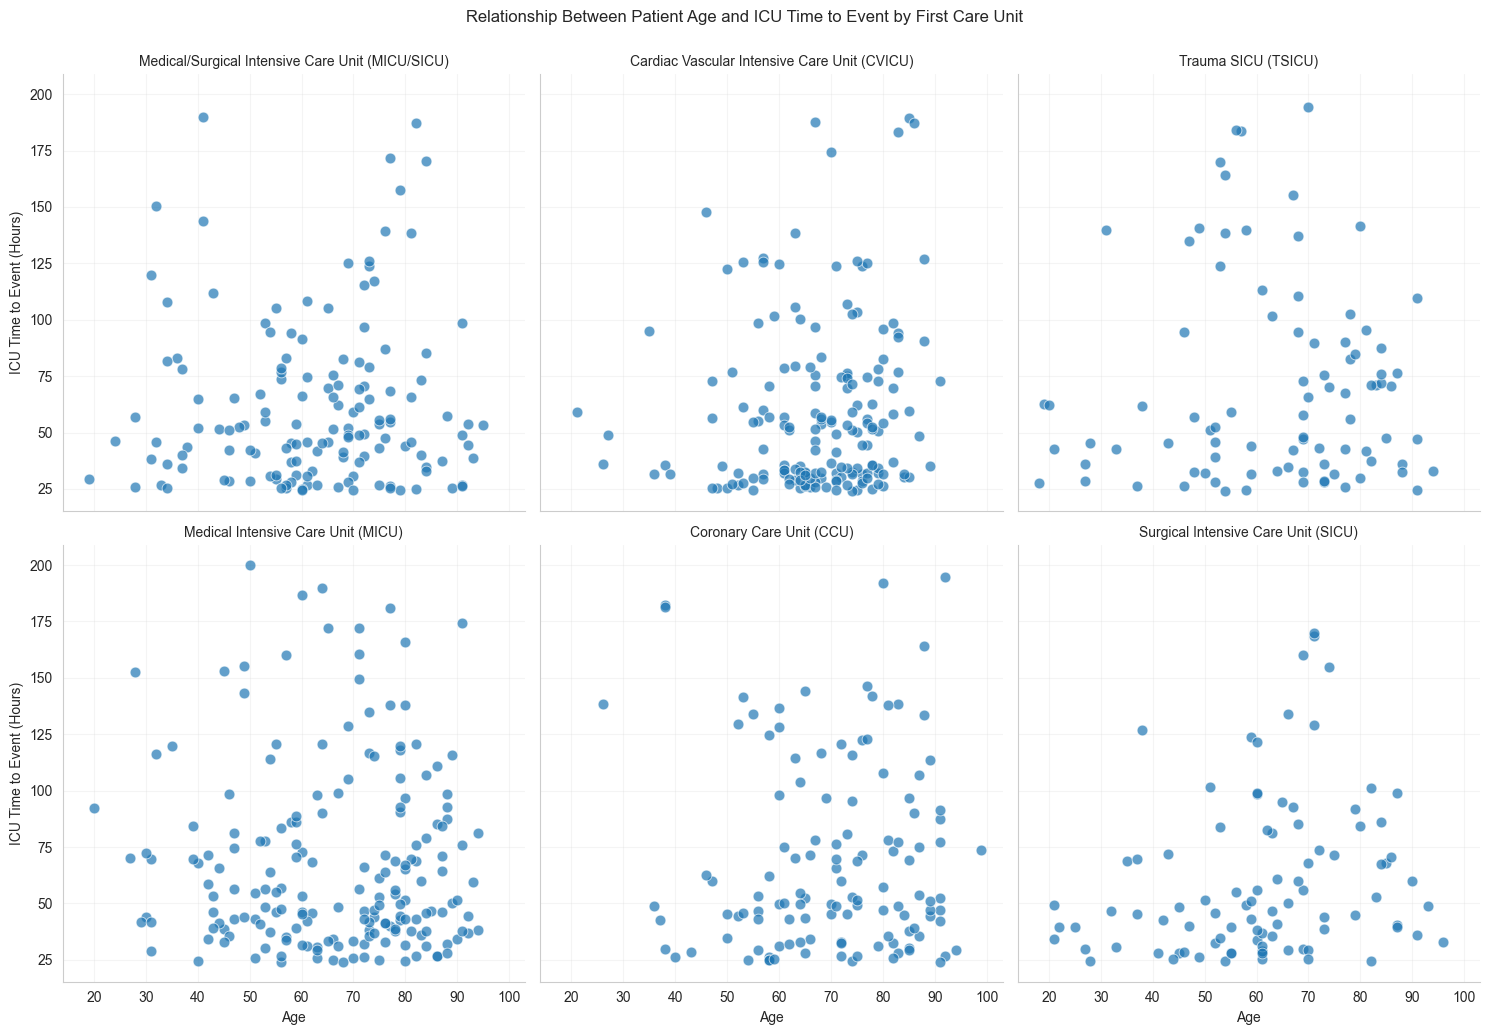

In [8]:
# Your code here . . .

import seaborn as sns
import matplotlib.pyplot as plt

clean_data = df.dropna(subset=["age", "ICU_time_to_event_hours", "first_careunit"])

clean_data = clean_data[
    (clean_data["age"] >= 18) &
    (clean_data["ICU_time_to_event_hours"] <= 200)
]

top_units = clean_data["first_careunit"].value_counts().head(6).index
clean_data = clean_data[clean_data["first_careunit"].isin(top_units)]

sample_data = clean_data.sample(800, random_state=42)

plot = sns.relplot(
    data=sample_data,
    x="age",
    y="ICU_time_to_event_hours",
    col="first_careunit",
    col_wrap=3,
    height=5,
    kind="scatter",
    s=60,
    alpha=0.7
)

plot.fig.set_size_inches(15, 10)
plot.fig.suptitle(
    "Relationship Between Patient Age and ICU Time to Event by First Care Unit",
    y=1.03
)

plot.set_titles("{col_name}")
for ax in plot.axes.flat:
    ax.grid(True, alpha=0.2)

plot.set_axis_labels("Age", "ICU Time to Event (Hours)")

plt.show()

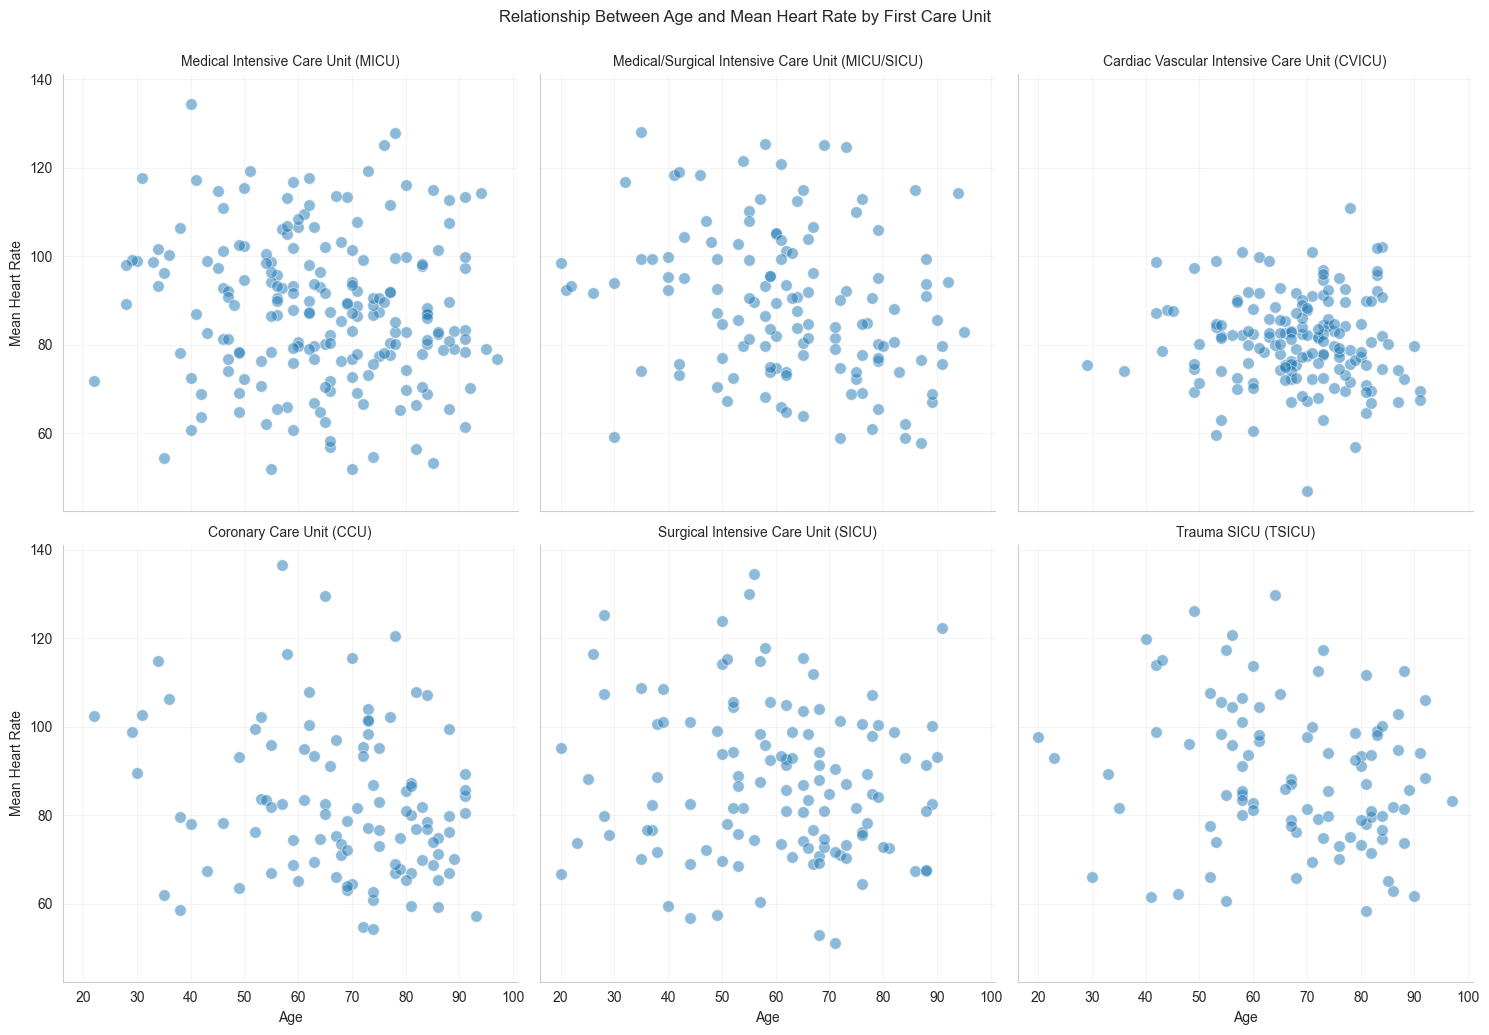

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

clean_data = df.dropna(subset=["age", "mean_val_heart_rate", "first_careunit"])

clean_data = clean_data[
    (clean_data["mean_val_heart_rate"] >= 40) &
    (clean_data["mean_val_heart_rate"] <= 150)
]

top_units = clean_data["first_careunit"].value_counts().head(6).index
clean_data = clean_data[clean_data["first_careunit"].isin(top_units)]


sample_data = clean_data.sample(800, random_state=42)

plot = sns.relplot(
    data=sample_data,
    x="age",
    y="mean_val_heart_rate",
    col="first_careunit",
    col_wrap=3,
    height=5,
    kind="scatter",
    s=70,
    alpha=0.5
)

plot.fig.set_size_inches(15, 10)
plot.fig.suptitle(
    "Relationship Between Age and Mean Heart Rate by First Care Unit",
    y=1.03
)

plot.set_titles("{col_name}")
for ax in plot.axes.flat:
    ax.grid(True, alpha=0.2)

plot.set_axis_labels("Age", "Mean Heart Rate")

plt.show()